# Final Project - Realized Volatility Timing

Ce notebook est le rendu principal: il finalise le backtest de stratégie options vu en cours et ajoute une couche de *timing* de volatilité réalisée (UKF + Heston).

Objectifs:
1. Construire une baseline carry (short strangle weekly).
2. Estimer une volatilité réalisée latente $\hat\sigma_t$ avec un modèle d'état Heston filtré par UKF.
3. Définir le spread $s_t = \sigma_{IV,t} - \hat\sigma_t$ et en déduire un poids dynamique d'allocation.
4. Comparer baseline vs stratégie timed avec des métriques interprétables.



## 1) Setup


In [1]:
%load_ext autoreload
%autoreload 2

from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from investment_lab.data.option_db import OptionLoader
from investment_lab.option_trade import OptionTrade
from investment_lab.backtest import BacktesterBidAskFromData
from investment_lab import option_strategies
from investment_lab.option_selection import select_options
from investment_lab.metrics.performance import sharpe_ratio, max_drawdown, calmar_ratio

from investment_lab.signals.vol_timing import (
    VolTimingConfig,
    build_iv_rv_timing_signal,
    apply_timing_weight_to_positions,
)


## 2) Paramètres du projet

Paramétrage volontairement simple, cohérent avec les slides de projet (L5):
- baseline carry: short strangle weekly
- signal: IV - RV_hat
- allocation: poids borné pour éviter les leviers excessifs


In [2]:

START = datetime(2020, 1, 6)
END = datetime(2022, 12, 4)
TICKER = "SPY"

# Stratégie carry baseline (vue en cours)
LEGS = option_strategies.SHORT_1W_STRANGLE_95_105

# Paramètres timing (simples)
signal_cfg = VolTimingConfig(
    rolling_window=126,  # ~6 mois
    min_obs=100,
    iv_col="implied_volatility",
    ret_col="log_return",
    base_weight=1.0,
    slope=2.0,
    min_weight=0.5,
    max_weight=1.5,
)


## 3) Construire les séries d'entrée du signal

- `log_return`: retour journalier du spot SPY
- `implied_volatility`: proxy IV daily (call ATM ~1M)

Remarque: on utilise un proxy IV volontairement robuste/simple pour garder un pipeline stable.


In [3]:

df_options = OptionLoader.load_data(START, END, process_kwargs={"ticker": TICKER})

# Spot quotidien
spot_daily = (
    df_options.groupby("date", as_index=False)["spot"]
    .first()
    .sort_values("date")
)
spot_daily["log_return"] = np.log(spot_daily["spot"]).diff()

# IV proxy: call proche ATM (moneyness=1), maturité proche 30j
iv_proxy = select_options(
    df_options,
    call_or_put="C",
    strike_col="moneyness",
    strike_target=1.0,
    day_to_expiry_target=30,
)[["date", "implied_volatility"]].drop_duplicates("date")

signal_input = (
    spot_daily[["date", "log_return"]]
    .merge(iv_proxy, on="date", how="inner")
    .dropna()
    .sort_values("date")
)

signal_input.head(), signal_input.tail()


(        date  log_return  implied_volatility
 1 2020-01-07   -0.002908             0.12111
 2 2020-01-08    0.005099             0.12157
 3 2020-01-09    0.006759             0.10737
 4 2020-01-10   -0.002913             0.10904
 5 2020-01-13    0.006977             0.10630,
           date  log_return  implied_volatility
 732 2022-11-28   -0.016035             0.20057
 733 2022-11-29   -0.001567             0.20750
 734 2022-11-30    0.030469             0.18750
 735 2022-12-01   -0.000344             0.18729
 736 2022-12-02   -0.001302             0.18172)

## 4) Estimation UKF-Heston et construction du signal de timing


In [4]:

df_signal = build_iv_rv_timing_signal(signal_input, config=signal_cfg)

df_signal[["date", "rv_hat", "spread", "timing_weight"]].tail()

signal_stats = df_signal[["rv_hat", "spread", "timing_weight"]].describe().T
signal_stats


,count,mean,std,min,25%,50%,75%,max
rv_hat,610.0,0.190176,0.105693,0.000001,0.119614,0.174307,0.257091,0.782491
spread,610.0,0.000562,0.088165,-0.650971,-0.025060,0.013431,0.041587,0.241089
timing_weight,610.0,1.008255,0.145318,0.500000,0.949881,1.026861,1.083173,1.482178


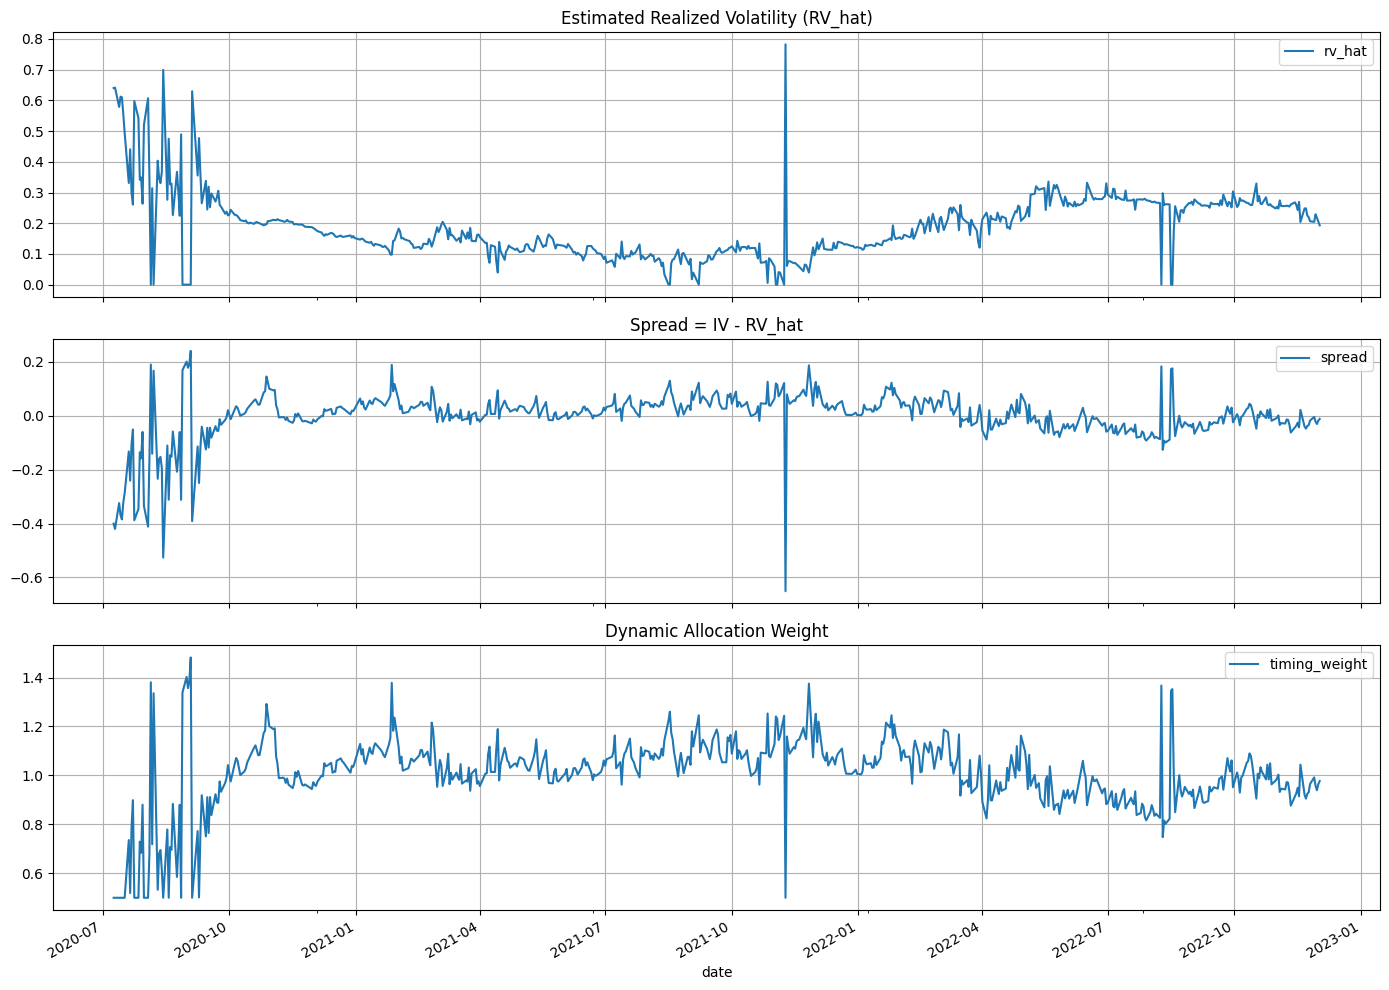

In [5]:
fig, ax = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

df_signal.set_index("date")[["rv_hat"]].plot(ax=ax[0], grid=True, title="Estimated Realized Volatility (RV_hat)")
df_signal.set_index("date")[["spread"]].plot(ax=ax[1], grid=True, title="Spread = IV - RV_hat")
df_signal.set_index("date")[["timing_weight"]].plot(ax=ax[2], grid=True, title="Dynamic Allocation Weight")

plt.tight_layout()


## 5) Baseline stratégie carry

On lance d'abord la stratégie sans timing pour établir un benchmark propre.


In [6]:

df_positions_baseline = OptionTrade.generate_trades(
    start_date=START,
    end_date=END,
    tickers=TICKER,
    legs=LEGS,
    cost_neutral=False,
)

bt_baseline = BacktesterBidAskFromData(df_positions_baseline).compute_backtest()
bt_baseline.nav.tail()


100%|██████████| 760/760 [00:03<00:00, 243.63it/s]


,NAV
2022-11-28,1.021711
2022-11-29,1.021753
2022-11-30,1.021640
2022-12-01,1.021884
2022-12-02,1.022060


## 6) Version timed (allocation dynamique)

Le poids de chaque trade est multiplié par `timing_weight` (par date).


In [7]:

df_positions_timed = apply_timing_weight_to_positions(df_positions_baseline, df_signal)

bt_timed = BacktesterBidAskFromData(df_positions_timed).compute_backtest()
bt_timed.nav.tail()


100%|██████████| 760/760 [00:03<00:00, 233.84it/s]


,NAV
2022-11-28,1.016944
2022-11-29,1.016984
2022-11-30,1.016877
2022-12-01,1.017112
2022-12-02,1.017284


## 7) Comparaison baseline vs timed

Lecture recommandée:
- NAV: domination visuelle d'une courbe sur l'autre
- Sharpe/Calmar: qualité rendement-risque
- Max drawdown: coût des phases adverses


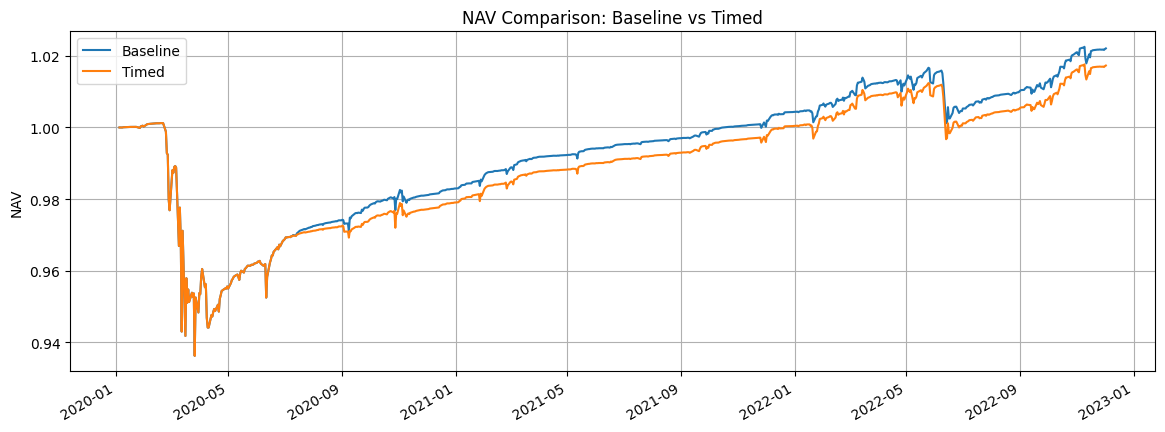

In [8]:

nav_compare = pd.concat(
    {
        "Baseline": bt_baseline.nav["NAV"],
        "Timed": bt_timed.nav["NAV"],
    },
    axis=1,
).dropna()

ax = nav_compare.plot(figsize=(14, 5), grid=True, title="NAV Comparison: Baseline vs Timed")
ax.set_ylabel("NAV")
plt.show()


In [9]:
def perf_table(nav_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in nav_df.columns:
        rets = nav_df[col].pct_change().dropna()
        rows.append(
            {
                "strategy": col,
                "sharpe": sharpe_ratio(rets),
                "max_drawdown": max_drawdown(nav_df[col]),
                "calmar": calmar_ratio(rets),
                "final_nav": nav_df[col].iloc[-1],
                "avg_daily_ret": rets.mean(),
                "daily_vol": rets.std(),
            }
        )
    return pd.DataFrame(rows).set_index("strategy").sort_values("final_nav", ascending=False)

perf = perf_table(nav_compare)
perf


,sharpe,max_drawdown,calmar,final_nav,avg_daily_ret,daily_vol
strategy,,,,,,
Baseline,0.191639,0.0,0.125440,1.022060,0.000032,0.002676
Timed,0.154772,0.0,0.101582,1.017284,0.000026,0.002683


## 8) Conclusion et interprétation

À commenter après exécution:
- Le signal UKF-Heston produit-il une variation exploitable du poids (ni trop bruitée, ni figée) ?
- La stratégie timed améliore-t-elle le couple rendement/risque vs baseline ?
- Les gains viennent-ils d'une hausse de performance ou d'une réduction des drawdowns ?

Checklist de robustesse (minimum attendu pour le rendu):
- Tester plusieurs fenêtres de calibration (63, 126, 252).
- Tester plusieurs pentes de mapping (`slope`).
- Vérifier la stabilité des résultats sur sous-périodes (ex: 2020 stress vs 2021-2022).
